In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

df=pd.read_csv('data/spambase_csv.csv')

In [2]:
len(df.columns),df.columns[-1]

(58, 'class')

In [3]:
X=df.iloc[:,:-1].values
y=df['class'].values
X.shape,y.shape

((4601, 57), (4601,))

In [4]:
X_train_raw,X_test_raw,y_train_raw,y_test_raw=train_test_split(X,y,test_size=0.2,random_state=42)

X_train=torch.tensor(X_train_raw,dtype=torch.float32)
X_test=torch.tensor(X_test_raw,dtype=torch.float32)

y_train=torch.tensor(y_train_raw,dtype=torch.float32).unsqueeze(1)
y_test=torch.tensor(y_test_raw,dtype=torch.float32).unsqueeze(1)

print("Preprocessing done")
print(X_train.shape)
print(y_train.shape)
# print()

Preprocessing done
torch.Size([3680, 57])
torch.Size([3680, 1])


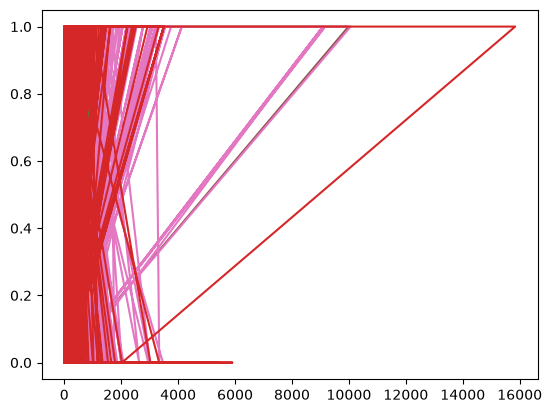

In [5]:
plt.plot(X_train,y_train)
plt.plot(X_test,y_test)
plt.show()

In [27]:
class spamDetector(nn.Module):
    def __init__(self,input_features=X_train.shape[1],hidden_units=16,out_features=1):
        super().__init__()
        self.layer_1=nn.Linear(input_features,hidden_units)
        self.layer_2=nn.Linear(hidden_units,out_features)
        self.relu=nn.ReLU()
    # def forward(self,x:torch.Tensor)->torch.Tensor:
    def forward(self,x):
        return self.layer_2(self.relu(self.layer_1(x)))

In [28]:
model_0=spamDetector()
# model_0.load_state_dict(torch.load(f="model_0.pth"))
print(model_0)
# list(model_0.parameters())
# model_0.state_dict()

spamDetector(
  (layer_1): Linear(in_features=57, out_features=16, bias=True)
  (layer_2): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
)


In [29]:
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(params=model_0.parameters(),lr=0.01)

In [30]:

# print(f"Number of testing samples: {len(X_test)}") 
# print(f"Number of predictions made: {len(y_preds)}")

In [31]:
# torch.manual_seed(42)
epochCount=[]
loss_values=[]
test_loss_values=[]

epochs=500
for epoch in range(epochs):
    model_0.train()
    y_logits=model_0(X_train)
    loss=loss_fn(y_logits,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model_0.eval()
    with torch.inference_mode():
        test_logits=model_0(X_test)
        test_loss=loss_fn(test_logits,y_test)
        epochCount.append(epoch)
        loss_values.append(loss.item())
        test_loss_values.append(test_loss.item())
    if epoch%10==0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

Epoch: 0 | Train Loss: 4.67055 | Test Loss: 3.58289
Epoch: 10 | Train Loss: 0.56668 | Test Loss: 0.57875
Epoch: 20 | Train Loss: 0.43002 | Test Loss: 0.46577
Epoch: 30 | Train Loss: 0.34858 | Test Loss: 0.36894
Epoch: 40 | Train Loss: 0.29591 | Test Loss: 0.30942
Epoch: 50 | Train Loss: 0.26215 | Test Loss: 0.26693
Epoch: 60 | Train Loss: 0.23656 | Test Loss: 0.23652
Epoch: 70 | Train Loss: 0.22091 | Test Loss: 0.22048
Epoch: 80 | Train Loss: 0.20910 | Test Loss: 0.20601
Epoch: 90 | Train Loss: 0.20093 | Test Loss: 0.20068
Epoch: 100 | Train Loss: 0.19442 | Test Loss: 0.19402
Epoch: 110 | Train Loss: 0.18804 | Test Loss: 0.18750
Epoch: 120 | Train Loss: 0.18368 | Test Loss: 0.19711
Epoch: 130 | Train Loss: 0.17883 | Test Loss: 0.18752
Epoch: 140 | Train Loss: 0.17740 | Test Loss: 0.18171
Epoch: 150 | Train Loss: 0.17000 | Test Loss: 0.17326
Epoch: 160 | Train Loss: 0.16991 | Test Loss: 0.17798
Epoch: 170 | Train Loss: 0.18312 | Test Loss: 0.19818
Epoch: 180 | Train Loss: 0.17947 | Test

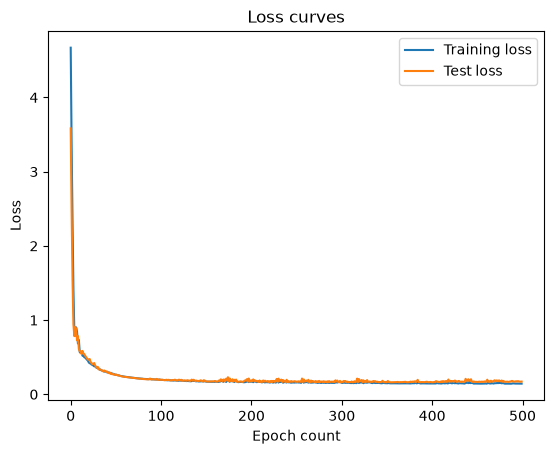

In [32]:
plt.plot(epochCount,loss_values,label="Training loss")
plt.plot(epochCount,test_loss_values,label="Test loss")
plt.title("Loss curves")
plt.xlabel("Epoch count")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [33]:
# torch.save(model_0.state_dict(),"model_0.pth")


In [34]:
# loaded_model_0=spamDetector()
# loaded_model_0.load_state_dict(torch.load(f="model_0.pth"))

In [35]:
# loaded_model_0.eval()
# with torch.inference_mode():
#     loaded_model_preds=loaded_model_0(X_test)
# loaded_model_preds==test_logits

In [36]:
# 1. Put the model in evaluation mode
model_0.eval()

# 2. Turn on inference mode for efficiency
with torch.inference_mode():
    # Get the raw outputs (logits) for the test set
    test_logits = model_0(X_test)
    
    # Pass logits through sigmoid to get prediction probabilities
    test_pred_probs = torch.sigmoid(test_logits)
    
    # Round the probabilities to get binary labels (0 or 1)
    # torch.round() converts >= 0.5 to 1.0, and < 0.5 to 0.0
    test_preds = torch.round(test_pred_probs)

# Let's inspect the first 5 samples to see the conversion in action!
print("First 5 Raw Logits:\n", test_logits[:5])
print("\nFirst 5 Prediction Probabilities:\n", test_pred_probs[:5])
print("\nFirst 5 Final Predictions (0=Ham, 1=Spam):\n", test_preds[:5])
print("\nFirst 5 True Labels:\n", y_test[:5])

First 5 Raw Logits:
 tensor([[-3.2630],
        [-2.9106],
        [-5.0631],
        [ 3.6999],
        [-6.0410]])

First 5 Prediction Probabilities:
 tensor([[0.0369],
        [0.0516],
        [0.0063],
        [0.9759],
        [0.0024]])

First 5 Final Predictions (0=Ham, 1=Spam):
 tensor([[0.],
        [0.],
        [0.],
        [1.],
        [0.]])

First 5 True Labels:
 tensor([[0.],
        [0.],
        [0.],
        [1.],
        [0.]])


In [37]:
# Calculate how many predictions match the actual true labels
correct_predictions = torch.eq(test_preds, y_test).sum().item()
total_samples = len(y_test)

test_accuracy = (correct_predictions / total_samples) * 100

print(f"Final Model Test Accuracy: {test_accuracy:.2f}%")

Final Model Test Accuracy: 94.68%
